In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_d")

print("✓ pandas version   :", pd.__version__)
print("✓ numpy version    :", np.__version__)
print("✓ matplotlib ready")
print("✓ seaborn ready")
print("")
print("All libraries loaded! Project ready to start.")

✓ pandas version   : 3.0.1
✓ numpy version    : 2.4.2
✓ matplotlib ready
✓ seaborn ready

All libraries loaded! Project ready to start.


In [3]:
# Cell 2 — Load all 7 CSV files
import os

data_path = "C:/Users/loukik/Downloads/e-commerces/"

orders    = pd.read_csv(data_path + "olist_orders_dataset.csv")
items     = pd.read_csv(data_path + "olist_order_items_dataset.csv")
payments  = pd.read_csv(data_path + "olist_order_payments_dataset.csv")
reviews   = pd.read_csv(data_path + "olist_order_reviews_dataset.csv")
customers = pd.read_csv(data_path + "olist_customers_dataset.csv")
products  = pd.read_csv(data_path + "olist_products_dataset.csv")
sellers   = pd.read_csv(data_path + "olist_sellers_dataset.csv")

datasets = {
    "orders"   : orders,
    "items"    : items,
    "payments" : payments,
    "reviews"  : reviews,
    "customers": customers,
    "products" : products,
    "sellers"  : sellers
}

print(f"{'Dataset':<12} {'Rows':>8} {'Columns':>9}")
print("-" * 32)
for name, df in datasets.items():
    print(f"{name:<12} {df.shape[0]:>8,} {df.shape[1]:>9}")

print("\n All 7 datasets loaded successfully!")

Dataset          Rows   Columns
--------------------------------
orders         99,441         8
items         112,650         7
payments      103,886         5
reviews        99,224         7
customers      99,441         5
products       32,951         9
sellers         3,095         4

 All 7 datasets loaded successfully!


In [4]:
print("=== SHAPE ===")
print(f"Rows: {orders.shape[0]:,}  |  Columns: {orders.shape[1]}")

print("\n=== COLUMN NAMES ===")
print(orders.columns.tolist())

print("\n=== FIRST 3 ROWS ===")
orders.head(3)

=== SHAPE ===
Rows: 99,441  |  Columns: 8

=== COLUMN NAMES ===
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

=== FIRST 3 ROWS ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [5]:
print("=== DATA TYPES ===")
print(orders.dtypes)

print("\n=== MISSING VALUES ===")
missing = orders.isnull().sum()
missing_pct = (orders.isnull().sum() / len(orders) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_df[missing_df['missing_count'] > 0])

print("\n=== ORDER STATUS BREAKDOWN ===")
print(orders['order_status'].value_counts())

=== DATA TYPES ===
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

=== MISSING VALUES ===
                               missing_count  missing_%
order_approved_at                        160       0.16
order_delivered_carrier_date            1783       1.79
order_delivered_customer_date           2965       2.98

=== ORDER STATUS BREAKDOWN ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [6]:
# Convert all date columns from string to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print("=== DATE COLUMNS AFTER FIX ===")
print(orders[date_cols].dtypes)

# Create delivery_days column
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

# Create month and year columns for trend analysis
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders['order_year']  = orders['order_purchase_timestamp'].dt.year

# Keep only delivered orders for revenue analysis
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

print(f"\n=== DELIVERED ORDERS ONLY ===")
print(f"Total orders    : {len(orders):,}")
print(f"Delivered orders: {len(orders_delivered):,}")
print(f"Dropped         : {len(orders) - len(orders_delivered):,}")

print(f"\n=== DELIVERY TIME STATS (days) ===")
print(orders_delivered['delivery_days'].describe().round(1))

=== DATE COLUMNS AFTER FIX ===
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

=== DELIVERED ORDERS ONLY ===
Total orders    : 99,441
Delivered orders: 96,478
Dropped         : 2,963

=== DELIVERY TIME STATS (days) ===
count   96470.00
mean       12.10
std         9.60
min         0.00
25%         6.00
50%        10.00
75%        15.00
max       209.00
Name: delivery_days, dtype: float64


In [7]:
# Step 1: merge orders + payments
order_payments = orders_delivered.merge(payments, on='order_id', how='left')

# Step 2: add customer info
order_payments = order_payments.merge(customers, on='customer_id', how='left')

print("=== MASTER TABLE SHAPE ===")
print(f"Rows: {order_payments.shape[0]:,}  |  Columns: {order_payments.shape[1]}")

# Step 3: monthly revenue
monthly_revenue = (
    order_payments.groupby('order_month')
    .agg(
        total_revenue = ('payment_value', 'sum'),
        total_orders  = ('order_id',      'nunique'),
        avg_order_val = ('payment_value', 'mean')
    )
    .reset_index()
)

monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)

print("\n=== MONTHLY REVENUE (first 6 months) ===")
print(monthly_revenue.head(6).to_string(index=False))

print(f"\n=== KEY REVENUE STATS ===")
print(f"Total revenue    : R$ {order_payments['payment_value'].sum():>12,.2f}")
print(f"Total orders     : {order_payments['order_id'].nunique():>12,}")
print(f"Avg order value  : R$ {order_payments['payment_value'].mean():>12,.2f}")
print(f"Best month rev   : R$ {monthly_revenue['total_revenue'].max():>12,.2f}")
print(f"Best month       :     {monthly_revenue.loc[monthly_revenue['total_revenue'].idxmax(), 'order_month']}")

=== MASTER TABLE SHAPE ===
Rows: 100,757  |  Columns: 19

=== MONTHLY REVENUE (first 6 months) ===
order_month  total_revenue  total_orders  avg_order_val
    2016-09           0.00             1            NaN
    2016-10       46566.71           265         165.13
    2016-12          19.62             1          19.62
    2017-01      127545.67           750         159.63
    2017-02      271298.65          1653         155.12
    2017-03      414369.39          2546         153.47

=== KEY REVENUE STATS ===
Total revenue    : R$ 15,422,461.77
Total orders     :       96,478
Avg order value  : R$       153.07
Best month rev   : R$ 1,153,528.05
Best month       :     2017-11


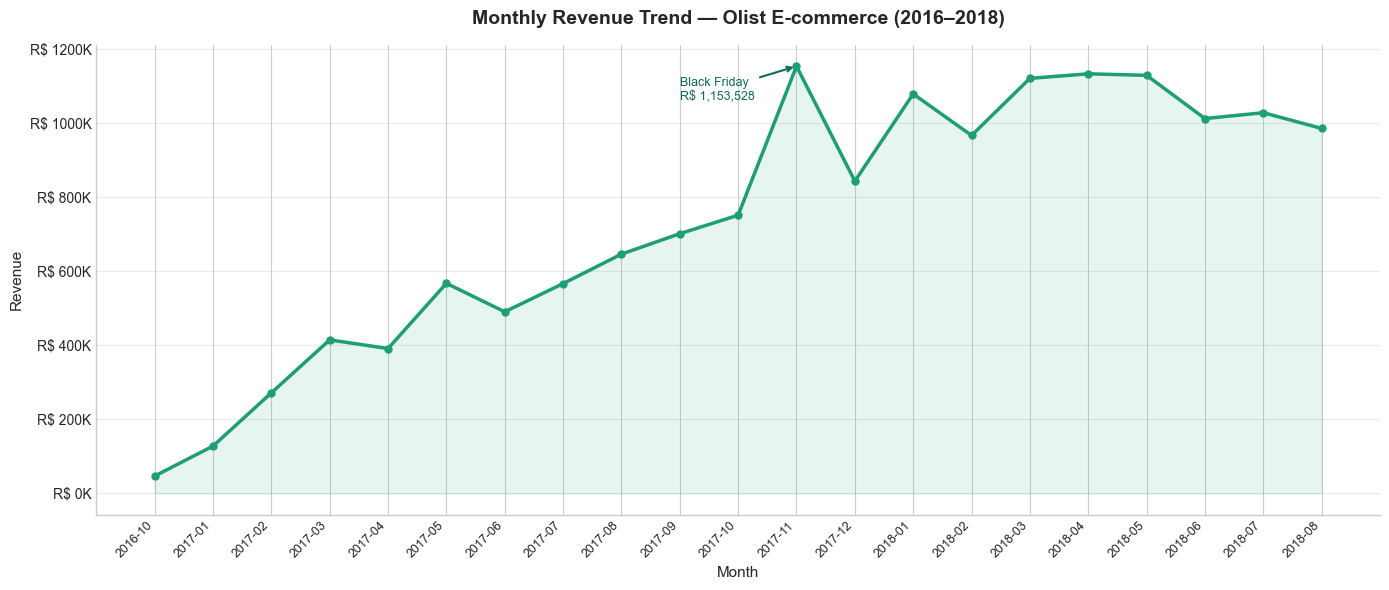

Chart saved to images/monthly_revenue_trend.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Remove incomplete/outlier months (2016-09 and 2016-12)
chart_data = monthly_revenue[
    ~monthly_revenue['order_month'].isin(['2016-09', '2016-12'])
].copy()

fig, ax = plt.subplots(figsize=(14, 6))

# Plot line + area fill
ax.plot(chart_data['order_month'], chart_data['total_revenue'],
        color='#1D9E75', linewidth=2.5, marker='o', markersize=5, zorder=3)
ax.fill_between(range(len(chart_data)), chart_data['total_revenue'],
                alpha=0.1, color='#1D9E75')

# Highlight best month (Nov 2017)
best_idx = chart_data['total_revenue'].idxmax()
best_pos = chart_data.index.get_loc(best_idx)
ax.annotate(
    f"Black Friday\nR$ {chart_data['total_revenue'].max():,.0f}",
    xy=(best_pos, chart_data['total_revenue'].max()),
    xytext=(best_pos - 2, chart_data['total_revenue'].max() * 0.92),
    fontsize=9, color='#0F6E56',
    arrowprops=dict(arrowstyle='->', color='#0F6E56', lw=1.5)
)

# Formatting
ax.set_xticks(range(len(chart_data)))
ax.set_xticklabels(chart_data['order_month'], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'R$ {x/1000:.0f}K'))
ax.set_title('Monthly Revenue Trend — Olist E-commerce (2016–2018)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue', fontsize=11)
ax.grid(axis='y', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

# Save to images folder
import os
os.makedirs('images', exist_ok=True)
plt.savefig('images/monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to images/monthly_revenue_trend.png")

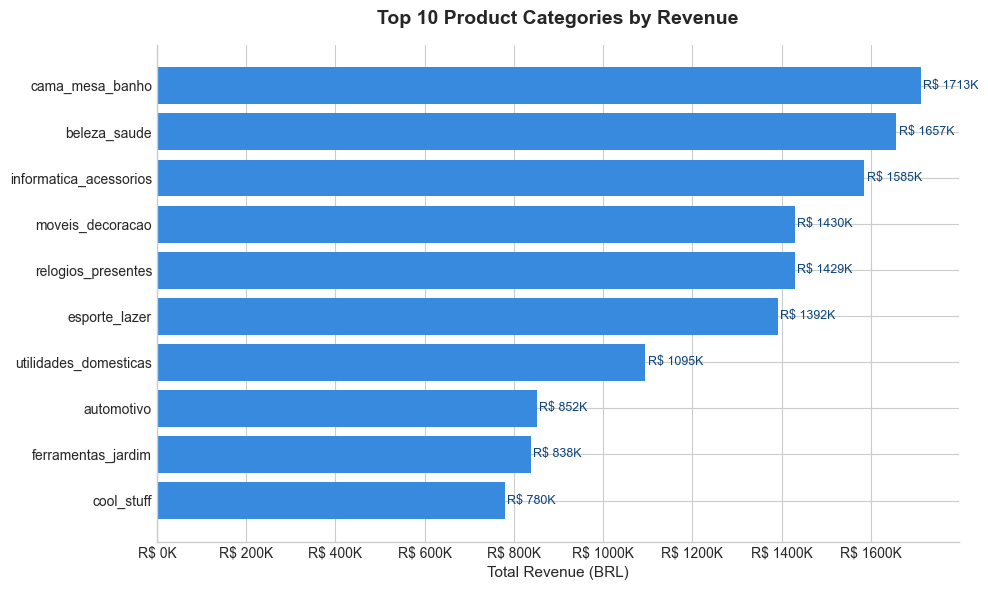

Chart saved!

Top category: cama_mesa_banho
Revenue: R$ 1,712,553.67


In [9]:
# Merge items + products + payments
cat_revenue = (
    items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
         .merge(payments[['order_id', 'payment_value']], on='order_id', how='left')
)

top10 = (
    cat_revenue.groupby('product_category_name')['payment_value']
    .sum()
    .nlargest(10)
    .sort_values()
    .reset_index()
)
top10.columns = ['category', 'revenue']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['category'], top10['revenue'], color='#378ADD', edgecolor='none')

# Add value labels on bars
for bar, val in zip(bars, top10['revenue']):
    ax.text(val + 5000, bar.get_y() + bar.get_height()/2,
            f'R$ {val/1000:.0f}K', va='center', fontsize=9, color='#0C447C')

ax.set_title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (BRL)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}K'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/top10_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")
print("\nTop category:", top10.iloc[-1]['category'])
print(f"Revenue: R$ {top10.iloc[-1]['revenue']:,.2f}")

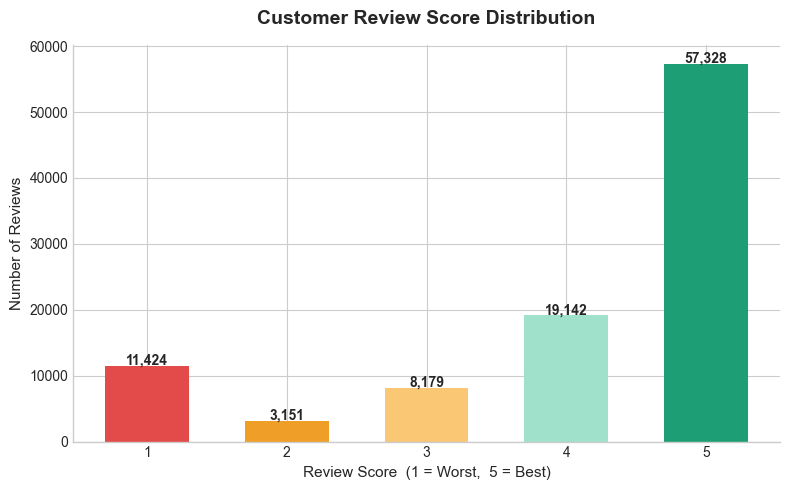

4-star + 5-star reviews : 77.1% of all reviews
5-star count            : 57,328
1-star count            : 11,424


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
score_counts = reviews['review_score'].value_counts().sort_index()
colors = ['#E24B4A', '#EF9F27', '#FAC775', '#9FE1CB', '#1D9E75']

bars = ax.bar(score_counts.index, score_counts.values,
              color=colors, edgecolor='none', width=0.6)

for bar, val in zip(bars, score_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Customer Review Score Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Review Score  (1 = Worst,  5 = Best)', fontsize=11)
ax.set_ylabel('Number of Reviews', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/review_scores.png', dpi=150, bbox_inches='tight')
plt.show()

total = score_counts.sum()
pct_positive = ((score_counts[4] + score_counts[5]) / total * 100).round(1)
print(f"4-star + 5-star reviews : {pct_positive}% of all reviews")
print(f"5-star count            : {score_counts[5]:,}")
print(f"1-star count            : {score_counts[1]:,}")

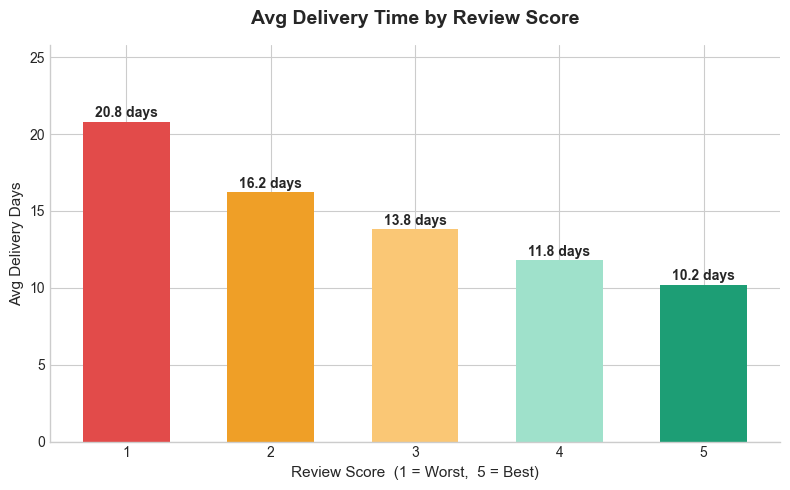

=== KEY INSIGHT ===
1-star orders avg delivery : 20.8 days
5-star orders avg delivery : 10.2 days
Difference                 : 10.6 days slower for 1-star


In [11]:
del_review = (
    orders_delivered[['order_id', 'delivery_days']]
    .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
    .dropna()
)

avg_del = del_review.groupby('review_score')['delivery_days'].mean().round(1)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#E24B4A', '#EF9F27', '#FAC775', '#9FE1CB', '#1D9E75']
bars = ax.bar(avg_del.index, avg_del.values, color=colors, edgecolor='none', width=0.6)

for bar, val in zip(bars, avg_del.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val} days', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Avg Delivery Time by Review Score', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Review Score  (1 = Worst,  5 = Best)', fontsize=11)
ax.set_ylabel('Avg Delivery Days', fontsize=11)
ax.set_ylim(0, avg_del.max() + 5)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/delivery_vs_score.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== KEY INSIGHT ===")
print(f"1-star orders avg delivery : {avg_del[1]} days")
print(f"5-star orders avg delivery : {avg_del[5]} days")
print(f"Difference                 : {(avg_del[1] - avg_del[5]):.1f} days slower for 1-star")

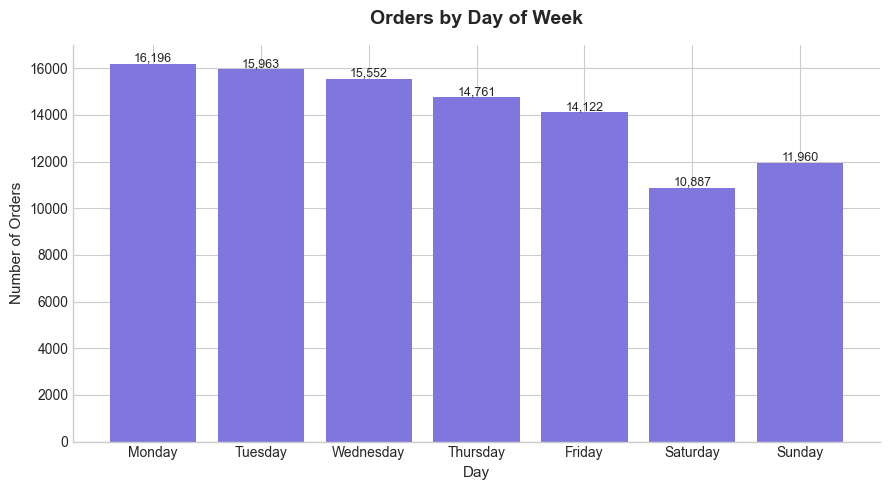

Busiest day : Monday (16,196 orders)
Quietest day: Saturday (10,887 orders)


In [12]:
orders['day_of_week'] = orders['order_purchase_timestamp'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = orders['day_of_week'].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(day_counts.index, day_counts.values, color='#7F77DD', edgecolor='none')

for bar, val in zip(bars, day_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', fontsize=9)

ax.set_title('Orders by Day of Week', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Day', fontsize=11)
ax.set_ylabel('Number of Orders', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/orders_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

print("Busiest day :", day_counts.idxmax(), f"({day_counts.max():,} orders)")
print("Quietest day:", day_counts.idxmin(), f"({day_counts.min():,} orders)")

=== CUSTOMER SEGMENTS ===
Segment       Customers   Total Revenue
----------------------------------------
Lost             30,136       4,771,490
Loyal            18,159       2,893,090
At Risk          18,071       2,890,234
Champions        18,013       2,923,049
Recent           12,099       1,944,598

Total customers segmented: 96,478


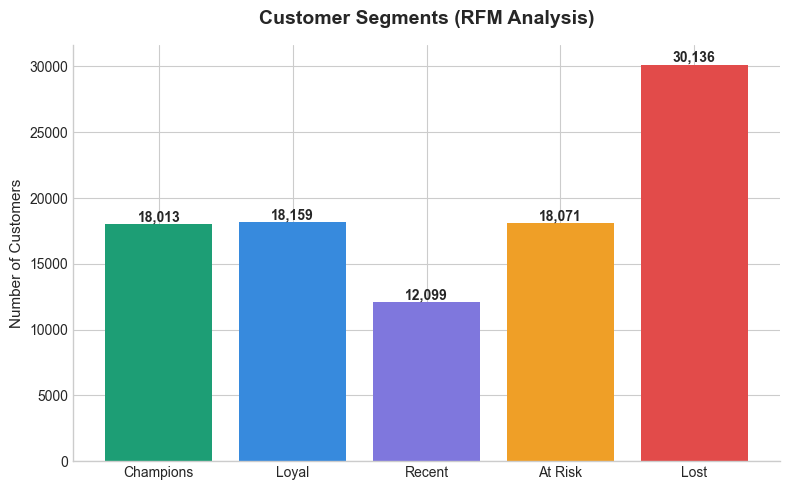

In [13]:
snapshot_date = orders['order_purchase_timestamp'].max()

rfm = (
    order_payments.groupby('customer_id')
    .agg(
        Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
        Frequency = ('order_id',                 'nunique'),
        Monetary  = ('payment_value',            'sum')
    )
    .reset_index()
)

# Score each dimension 1–4
rfm['R'] = pd.qcut(rfm['Recency'],   4, labels=[4, 3, 2, 1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M'] = pd.qcut(rfm['Monetary'],  4, labels=[1, 2, 3, 4])
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str)

# Segment labels
def segment(row):
    score = row['RFM_Score']
    if score in ['44', '43', '34']:  return 'Champions'
    elif score in ['42', '33', '32']: return 'Loyal'
    elif score in ['41', '31']:       return 'Recent'
    elif score in ['24', '23', '14']: return 'At Risk'
    else:                             return 'Lost'

rfm['Segment'] = rfm.apply(segment, axis=1)

seg_counts = rfm['Segment'].value_counts()
seg_revenue = rfm.groupby('Segment')['Monetary'].sum().round(0)

print("=== CUSTOMER SEGMENTS ===")
print(f"{'Segment':<12} {'Customers':>10} {'Total Revenue':>15}")
print("-" * 40)
for seg in seg_counts.index:
    print(f"{seg:<12} {seg_counts[seg]:>10,} {seg_revenue[seg]:>15,.0f}")

print(f"\nTotal customers segmented: {len(rfm):,}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
colors_seg = {'Champions':'#1D9E75','Loyal':'#378ADD',
              'Recent':'#7F77DD','At Risk':'#EF9F27','Lost':'#E24B4A'}
seg_plot = seg_counts.reindex(['Champions','Loyal','Recent','At Risk','Lost'])
bars = ax.bar(seg_plot.index, seg_plot.values,
              color=[colors_seg[s] for s in seg_plot.index], edgecolor='none')

for bar, val in zip(bars, seg_plot.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Customer Segments (RFM Analysis)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
print("=" * 55)
print("   PROJECT 1 — ECOMMERCE ANALYSIS SUMMARY")
print("=" * 55)

print(f"\n REVENUE")
print(f"  Total revenue          : R$ {order_payments['payment_value'].sum():>12,.2f}")
print(f"  Avg order value        : R$ {order_payments['payment_value'].mean():>12,.2f}")
print(f"  Best month             :     {monthly_revenue.loc[monthly_revenue['total_revenue'].idxmax(), 'order_month']} (Black Friday)")

print(f"\n ORDERS")
print(f"  Total orders           : {len(orders):>12,}")
print(f"  Delivered              : {len(orders_delivered):>12,}")
print(f"  Cancellation rate      : {(orders['order_status'].eq('canceled').sum()/len(orders)*100):>11.1f}%")

print(f"\n DELIVERY")
print(f"  Avg delivery time      : {orders_delivered['delivery_days'].mean():>11.1f} days")
print(f"  1-star avg delivery    : {avg_del[1]:>11.1f} days")
print(f"  5-star avg delivery    : {avg_del[5]:>11.1f} days")

print(f"\n CUSTOMERS")
print(f"  Total customers        : {len(rfm):>12,}")
print(f"  Champions              : {seg_counts.get('Champions',0):>12,}")
print(f"  At Risk                : {seg_counts.get('At Risk',0):>12,}")

print(f"\n REVIEWS")
print(f"  Positive (4+5 star)    : {pct_positive:>11.1f}%")
print(f"  5-star reviews         : {score_counts[5]:>12,}")

print("\n" + "=" * 55)
print("  5 charts saved in images/ folder")
print("  Python EDA complete — ready for Power BI!")
print("=" * 55)

   PROJECT 1 — ECOMMERCE ANALYSIS SUMMARY

 REVENUE
  Total revenue          : R$ 15,422,461.77
  Avg order value        : R$       153.07
  Best month             :     2017-11 (Black Friday)

 ORDERS
  Total orders           :       99,441
  Delivered              :       96,478
  Cancellation rate      :         0.6%

 DELIVERY
  Avg delivery time      :        12.1 days
  1-star avg delivery    :        20.8 days
  5-star avg delivery    :        10.2 days

 CUSTOMERS
  Total customers        :       96,478
  Champions              :       18,013
  At Risk                :       18,071

 REVIEWS
  Positive (4+5 star)    :        77.1%
  5-star reviews         :       57,328

  5 charts saved in images/ folder
  Python EDA complete — ready for Power BI!


In [15]:
import os
os.makedirs('output', exist_ok=True)

monthly_revenue.to_csv('output/monthly_revenue.csv', index=False)
top10.to_csv('output/top10_categories.csv', index=False)
rfm.to_csv('output/rfm_segments.csv', index=False)
del_review.groupby('review_score')['delivery_days'].mean().reset_index().to_csv(
    'output/delivery_by_score.csv', index=False)
day_counts.reset_index().to_csv('output/orders_by_day.csv', index=False)

print("Saved to output/ folder:")
for f in os.listdir('output'):
    size = os.path.getsize(f'output/{f}')
    print(f"  {f:<35} {size:>8,} bytes")

print("\nNext step: MySQL Workbench")

Saved to output/ folder:
  delivery_by_score.csv                    147 bytes
  monthly_revenue.csv                      991 bytes
  orders_by_day.csv                        125 bytes
  rfm_segments.csv                    6,009,816 bytes
  sql_delivery_by_score.csv                112 bytes
  sql_monthly_revenue.csv                  707 bytes
  sql_payment_methods.csv                  215 bytes
  sql_revenue_by_state.csv                 671 bytes
  sql_top10_categories.csv                 441 bytes
  top10_categories.csv                     299 bytes

Next step: MySQL Workbench


In [16]:
import sqlite3

# Fix: convert Period columns to string before loading into SQLite
orders_sql = orders.copy()
orders_sql['order_month'] = orders_sql['order_month'].astype(str)
orders_sql['order_purchase_timestamp']      = orders_sql['order_purchase_timestamp'].astype(str)
orders_sql['order_approved_at']             = orders_sql['order_approved_at'].astype(str)
orders_sql['order_delivered_carrier_date']  = orders_sql['order_delivered_carrier_date'].astype(str)
orders_sql['order_delivered_customer_date'] = orders_sql['order_delivered_customer_date'].astype(str)
orders_sql['order_estimated_delivery_date'] = orders_sql['order_estimated_delivery_date'].astype(str)

# Create database file
conn = sqlite3.connect('ecommerce.db')

# Load all tables
orders_sql.to_sql('orders',     conn, if_exists='replace', index=False)
items.to_sql('order_items',     conn, if_exists='replace', index=False)
payments.to_sql('payments',     conn, if_exists='replace', index=False)
reviews.to_sql('reviews',       conn, if_exists='replace', index=False)
customers.to_sql('customers',   conn, if_exists='replace', index=False)
products.to_sql('products',     conn, if_exists='replace', index=False)
sellers.to_sql('sellers',       conn, if_exists='replace', index=False)

# Confirm
print("Tables loaded into SQLite:")
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
for row in cursor.fetchall():
    cursor.execute(f"SELECT COUNT(*) FROM {row[0]}")
    count = cursor.fetchone()[0]
    print(f"  {row[0]:<15} {count:>8,} rows")

print("\necommerce.db created successfully!")
print(f"File location: ecommerce.db in your project folder")

Tables loaded into SQLite:
  orders            99,441 rows
  order_items      112,650 rows
  payments         103,886 rows
  reviews           99,224 rows
  customers         99,441 rows
  products          32,951 rows
  sellers            3,095 rows

ecommerce.db created successfully!
File location: ecommerce.db in your project folder


In [17]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('ecommerce.db')

query1 = """
SELECT 
    order_month,
    ROUND(SUM(p.payment_value), 2)     AS total_revenue,
    COUNT(DISTINCT o.order_id)          AS total_orders,
    ROUND(AVG(p.payment_value), 2)      AS avg_order_value
FROM orders o
JOIN payments p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
  AND o.order_month NOT IN ('2016-09', '2016-12')
GROUP BY o.order_month
ORDER BY o.order_month;
"""

result1 = pd.read_sql_query(query1, conn)
print("=== MONTHLY REVENUE (SQL) ===")
print(result1.to_string(index=False))

=== MONTHLY REVENUE (SQL) ===
order_month  total_revenue  total_orders  avg_order_value
    2016-10       46566.71           265           165.13
    2017-01      127545.67           750           159.63
    2017-02      271298.65          1653           155.12
    2017-03      414369.39          2546           153.47
    2017-04      390952.18          2303           160.49
    2017-05      567066.73          3546           149.74
    2017-06      490225.60          3135           147.53
    2017-07      566403.93          3872           136.58
    2017-08      646000.61          4193           147.05
    2017-09      701169.99          4150           160.41
    2017-10      751140.27          4478           159.89
    2017-11     1153528.05          7289           151.92
    2017-12      843199.17          5513           147.18
    2018-01     1078606.86          7069           146.73
    2018-02      966510.88          6555           142.64
    2018-03     1120678.00          7003  

In [18]:
query2 = """
SELECT 
    p.product_category_name             AS category,
    ROUND(SUM(oi.price), 2)             AS total_revenue,
    COUNT(DISTINCT oi.order_id)         AS total_orders,
    ROUND(AVG(oi.price), 2)             AS avg_price
FROM order_items oi
JOIN products p  ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY total_revenue DESC
LIMIT 10;
"""

result2 = pd.read_sql_query(query2, conn)
print("=== TOP 10 CATEGORIES (SQL) ===")
print(result2.to_string(index=False))

=== TOP 10 CATEGORIES (SQL) ===
              category  total_revenue  total_orders  avg_price
          beleza_saude     1258681.34          8836     130.16
    relogios_presentes     1205005.68          5624     201.14
       cama_mesa_banho     1036988.68          9417      93.30
         esporte_lazer      988048.97          7720     114.34
informatica_acessorios      911954.32          6689     116.51
      moveis_decoracao      729762.49          6449      87.56
            cool_stuff      635290.85          3632     167.36
 utilidades_domesticas      632248.66          5884      90.79
            automotivo      592720.11          3897     139.96
    ferramentas_jardim      485256.46          3518     111.63


In [19]:
query3 = """
SELECT 
    c.customer_state                        AS state,
    ROUND(AVG(o.delivery_days), 1)          AS avg_delivery_days,
    COUNT(*)                                AS total_orders
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
  AND o.delivery_days IS NOT NULL
GROUP BY c.customer_state
HAVING total_orders > 100
ORDER BY avg_delivery_days DESC
LIMIT 10;
"""

result3 = pd.read_sql_query(query3, conn)
print("=== SLOWEST DELIVERY STATES (SQL) ===")
print(result3.to_string(index=False))

=== SLOWEST DELIVERY STATES (SQL) ===
state  avg_delivery_days  total_orders
   AM              26.00           145
   AL              24.00           397
   PA              23.30           946
   MA              21.10           717
   SE              21.00           335
   CE              20.80          1279
   PB              20.00           517
   PI              19.00           476
   RO              18.90           243
   BA              18.90          3256


In [20]:
# Cell 19 — SQL Query 4: Review score vs delivery time
# This is the most important insight — interviewers LOVE this one
query4 = """
SELECT 
    r.review_score,
    ROUND(AVG(o.delivery_days), 1)      AS avg_delivery_days,
    COUNT(*)                            AS total_orders,
    ROUND(COUNT(*) * 100.0 / 
        SUM(COUNT(*)) OVER(), 1)        AS pct_of_total
FROM orders o
JOIN reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.delivery_days IS NOT NULL
GROUP BY r.review_score
ORDER BY r.review_score;
"""

result4 = pd.read_sql_query(query4, conn)
print("=== REVIEW SCORE vs DELIVERY TIME (SQL) ===")
print(result4.to_string(index=False))

=== REVIEW SCORE vs DELIVERY TIME (SQL) ===
 review_score  avg_delivery_days  total_orders  pct_of_total
            1              20.80          9405          9.80
            2              16.20          2941          3.10
            3              13.80          7961          8.30
            4              11.80         18987         19.70
            5              10.20         57059         59.20


In [21]:
# Cell 20 — SQL Query 5: Payment method breakdown
query5 = """
SELECT 
    payment_type,
    COUNT(*)                            AS total_transactions,
    ROUND(SUM(payment_value), 2)        AS total_revenue,
    ROUND(AVG(payment_value), 2)        AS avg_payment,
    ROUND(COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER(), 1)        AS pct_of_transactions
FROM payments
GROUP BY payment_type
ORDER BY total_transactions DESC;
"""

result5 = pd.read_sql_query(query5, conn)
print("=== PAYMENT METHOD BREAKDOWN (SQL) ===")
print(result5.to_string(index=False))

=== PAYMENT METHOD BREAKDOWN (SQL) ===
payment_type  total_transactions  total_revenue  avg_payment  pct_of_transactions
 credit_card               76795    12542084.19       163.32                73.90
      boleto               19784     2869361.27       145.03                19.00
     voucher                5775      379436.87        65.70                 5.60
  debit_card                1529      217989.79       142.57                 1.50
 not_defined                   3           0.00         0.00                 0.00


In [22]:
# Cell 21 — SQL Query 6: Top 10 customers by revenue (VIP customers)
query6 = """
SELECT 
    c.customer_state                    AS state,
    COUNT(DISTINCT o.order_id)          AS total_orders,
    ROUND(SUM(p.payment_value), 2)      AS total_spent,
    ROUND(AVG(p.payment_value), 2)      AS avg_order_value,
    ROUND(AVG(o.delivery_days), 1)      AS avg_delivery_days
FROM orders o
JOIN customers c  ON o.customer_id  = c.customer_id
JOIN payments p   ON o.order_id     = p.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
ORDER BY total_spent DESC
LIMIT 10;
"""

result6 = pd.read_sql_query(query6, conn)
print("=== TOP 10 STATES BY REVENUE (SQL) ===")
print(result6.to_string(index=False))

conn.close()
print("\nAll 6 SQL queries completed!")
print("ecommerce.db connection closed.")

=== TOP 10 STATES BY REVENUE (SQL) ===
state  total_orders  total_spent  avg_order_value  avg_delivery_days
   SP         40500   5770266.19           136.39               8.30
   RJ         12350   2055690.45           158.08              14.90
   MG         11354   1819277.61           154.12              11.50
   RS          5345    861802.40           155.45              14.80
   PR          4923    781919.55           152.45              11.60
   SC          3546    595208.40           162.58              14.50
   BA          3256    591270.60           169.76              18.80
   DF          2080    346146.17           161.60              12.50
   GO          1957    334294.22           163.31              15.10
   ES          1995    317682.65           153.62              15.40

All 6 SQL queries completed!
ecommerce.db connection closed.


In [23]:
# Cell 22 — Save all SQL results to output folder
import sqlite3
import pandas as pd

conn = sqlite3.connect('ecommerce.db')

queries = {
    'sql_monthly_revenue': """
        SELECT order_month,
               ROUND(SUM(p.payment_value),2) AS total_revenue,
               COUNT(DISTINCT o.order_id)     AS total_orders,
               ROUND(AVG(p.payment_value),2)  AS avg_order_value
        FROM orders o
        JOIN payments p ON o.order_id = p.order_id
        WHERE o.order_status = 'delivered'
          AND o.order_month NOT IN ('2016-09','2016-12')
        GROUP BY o.order_month
        ORDER BY o.order_month
    """,
    'sql_top10_categories': """
        SELECT p.product_category_name      AS category,
               ROUND(SUM(oi.price),2)       AS total_revenue,
               COUNT(DISTINCT oi.order_id)  AS total_orders,
               ROUND(AVG(oi.price),2)       AS avg_price
        FROM order_items oi
        JOIN products p ON oi.product_id = p.product_id
        GROUP BY p.product_category_name
        ORDER BY total_revenue DESC
        LIMIT 10
    """,
    'sql_delivery_by_score': """
        SELECT r.review_score,
               ROUND(AVG(o.delivery_days),1) AS avg_delivery_days,
               COUNT(*)                       AS total_orders
        FROM orders o
        JOIN reviews r ON o.order_id = r.order_id
        WHERE o.order_status = 'delivered'
          AND o.delivery_days IS NOT NULL
        GROUP BY r.review_score
        ORDER BY r.review_score
    """,
    'sql_payment_methods': """
        SELECT payment_type,
               COUNT(*)                   AS total_transactions,
               ROUND(SUM(payment_value),2) AS total_revenue,
               ROUND(AVG(payment_value),2) AS avg_payment
        FROM payments
        GROUP BY payment_type
        ORDER BY total_transactions DESC
    """,
    'sql_revenue_by_state': """
        SELECT c.customer_state           AS state,
               COUNT(DISTINCT o.order_id) AS total_orders,
               ROUND(SUM(p.payment_value),2) AS total_spent,
               ROUND(AVG(o.delivery_days),1) AS avg_delivery_days
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        JOIN payments p  ON o.order_id    = p.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_state
        ORDER BY total_spent DESC
    """
}

import os
os.makedirs('output', exist_ok=True)

for filename, query in queries.items():
    df = pd.read_sql_query(query, conn)
    df.to_csv(f'output/{filename}.csv', index=False)
    print(f"  Saved {filename}.csv — {len(df):,} rows")

conn.close()
print("\nAll SQL results saved to output/ folder!")
print("SQL phase complete!")

  Saved sql_monthly_revenue.csv — 21 rows
  Saved sql_top10_categories.csv — 10 rows
  Saved sql_delivery_by_score.csv — 5 rows
  Saved sql_payment_methods.csv — 5 rows
  Saved sql_revenue_by_state.csv — 27 rows

All SQL results saved to output/ folder!
SQL phase complete!


In [24]:
# Cell 23 — Create a single-row summary table for Power BI KPI cards
import sqlite3
conn = sqlite3.connect('ecommerce.db')

summary = pd.DataFrame({
    'total_revenue':    [round(order_payments['payment_value'].sum(), 2)],
    'total_orders':     [len(orders)],
    'avg_order_value':  [round(order_payments['payment_value'].mean(), 2)],
    'avg_delivery_days':[round(orders_delivered['delivery_days'].mean(), 1)],
    'delivered_orders': [len(orders_delivered)],
    'cancellation_rate':[round(orders['order_status'].eq('canceled').sum()/len(orders)*100, 1)],
    'positive_reviews': [77.1],
    'best_month':       ['Nov 2017']
})

summary.to_csv('output/summary_kpis.csv', index=False)
print(summary.to_string(index=False))
print("\nSaved to output/summary_kpis.csv")

conn.close()

 total_revenue  total_orders  avg_order_value  avg_delivery_days  delivered_orders  cancellation_rate  positive_reviews best_month
   15422461.77         99441           153.07              12.10             96478               0.60             77.10   Nov 2017

Saved to output/summary_kpis.csv
